In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data=r"C:\Users\PC\OneDrive\Desktop\work\home-credit-default-risk\application_train.csv"
df=pd.read_csv(data,nrows=100000)
df.shape

(100000, 122)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 93.1+ MB


In [3]:
df["TARGET"].value_counts()

TARGET
0    91907
1     8093
Name: count, dtype: int64

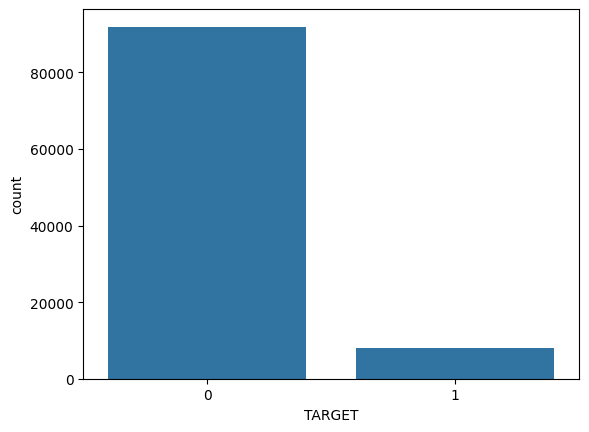

In [4]:
sns.countplot(x="TARGET",data=df)
plt.show()

In [5]:
missing=df.isnull().sum().sort_values(ascending=False)
missing_percent=(missing/len(df))*100
print(missing_percent)
missing_df=pd.DataFrame({
    "missing count":missing,
    "missing %":missing_percent
})
print(missing_df)

COMMONAREA_MEDI             69.732
COMMONAREA_AVG              69.732
COMMONAREA_MODE             69.732
NONLIVINGAPARTMENTS_MODE    69.275
NONLIVINGAPARTMENTS_AVG     69.275
                             ...  
NAME_HOUSING_TYPE            0.000
NAME_FAMILY_STATUS           0.000
NAME_EDUCATION_TYPE          0.000
NAME_INCOME_TYPE             0.000
SK_ID_CURR                   0.000
Length: 122, dtype: float64
                          missing count  missing %
COMMONAREA_MEDI                   69732     69.732
COMMONAREA_AVG                    69732     69.732
COMMONAREA_MODE                   69732     69.732
NONLIVINGAPARTMENTS_MODE          69275     69.275
NONLIVINGAPARTMENTS_AVG           69275     69.275
...                                 ...        ...
NAME_HOUSING_TYPE                     0      0.000
NAME_FAMILY_STATUS                    0      0.000
NAME_EDUCATION_TYPE                   0      0.000
NAME_INCOME_TYPE                      0      0.000
SK_ID_CURR                

In [6]:
cols_drop=missing_df[missing_df["missing %"]>50].index
df=df.drop(cols_drop,axis=1,errors="ignore")

In [7]:
df.info()
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    100000 non-null  int64  
 1   TARGET                        100000 non-null  int64  
 2   NAME_CONTRACT_TYPE            100000 non-null  object 
 3   CODE_GENDER                   100000 non-null  object 
 4   FLAG_OWN_CAR                  100000 non-null  object 
 5   FLAG_OWN_REALTY               100000 non-null  object 
 6   CNT_CHILDREN                  100000 non-null  int64  
 7   AMT_INCOME_TOTAL              100000 non-null  float64
 8   AMT_CREDIT                    100000 non-null  float64
 9   AMT_ANNUITY                   99993 non-null   float64
 10  AMT_GOODS_PRICE               99919 non-null   float64
 11  NAME_TYPE_SUITE               99595 non-null   object 
 12  NAME_INCOME_TYPE              100000 non-null

In [8]:

num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())
df.info()


SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 81, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    100000 non-null  int64  
 1   TARGET                        100000 non-null  int64  
 2   NAME_CONTRACT_TYPE            100000 non-null  object 
 3   CODE_GENDER                   100000 non-null  object 
 4   FLAG_OWN_CAR                  100000 non-null  object 
 5   FLAG_OWN_REALTY               100000 non-null  object 
 6   CNT_CHILDREN                

In [9]:
cat_cols=df.select_dtypes(include="object").columns
binary_cols=[]
multi_cols=[]
for col in cat_cols:
    if df[col].nunique()==2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)
print("BINARY COLS=",binary_cols)
print("MULTI COLS=",multi_cols)

BINARY COLS= ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']
MULTI COLS= ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in binary_cols:
    df[col]=le.fit_transform(df[col])
df=pd.get_dummies(df,columns=multi_cols,drop_first=True)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 181 entries, SK_ID_CURR to ORGANIZATION_TYPE_XNA
dtypes: bool(109), float64(27), int32(4), int64(41)
memory usage: 63.8 MB
None


TARGET                                  1.000000
DAYS_BIRTH                              0.076838
REGION_RATING_CLIENT_W_CITY             0.062816
REGION_RATING_CLIENT                    0.061597
NAME_INCOME_TYPE_Working                0.057063
                                          ...   
ORGANIZATION_TYPE_XNA                  -0.044397
NAME_INCOME_TYPE_Pensioner             -0.044725
NAME_EDUCATION_TYPE_Higher education   -0.057679
EXT_SOURCE_3                           -0.155862
EXT_SOURCE_2                           -0.161536
Name: TARGET, Length: 181, dtype: float64


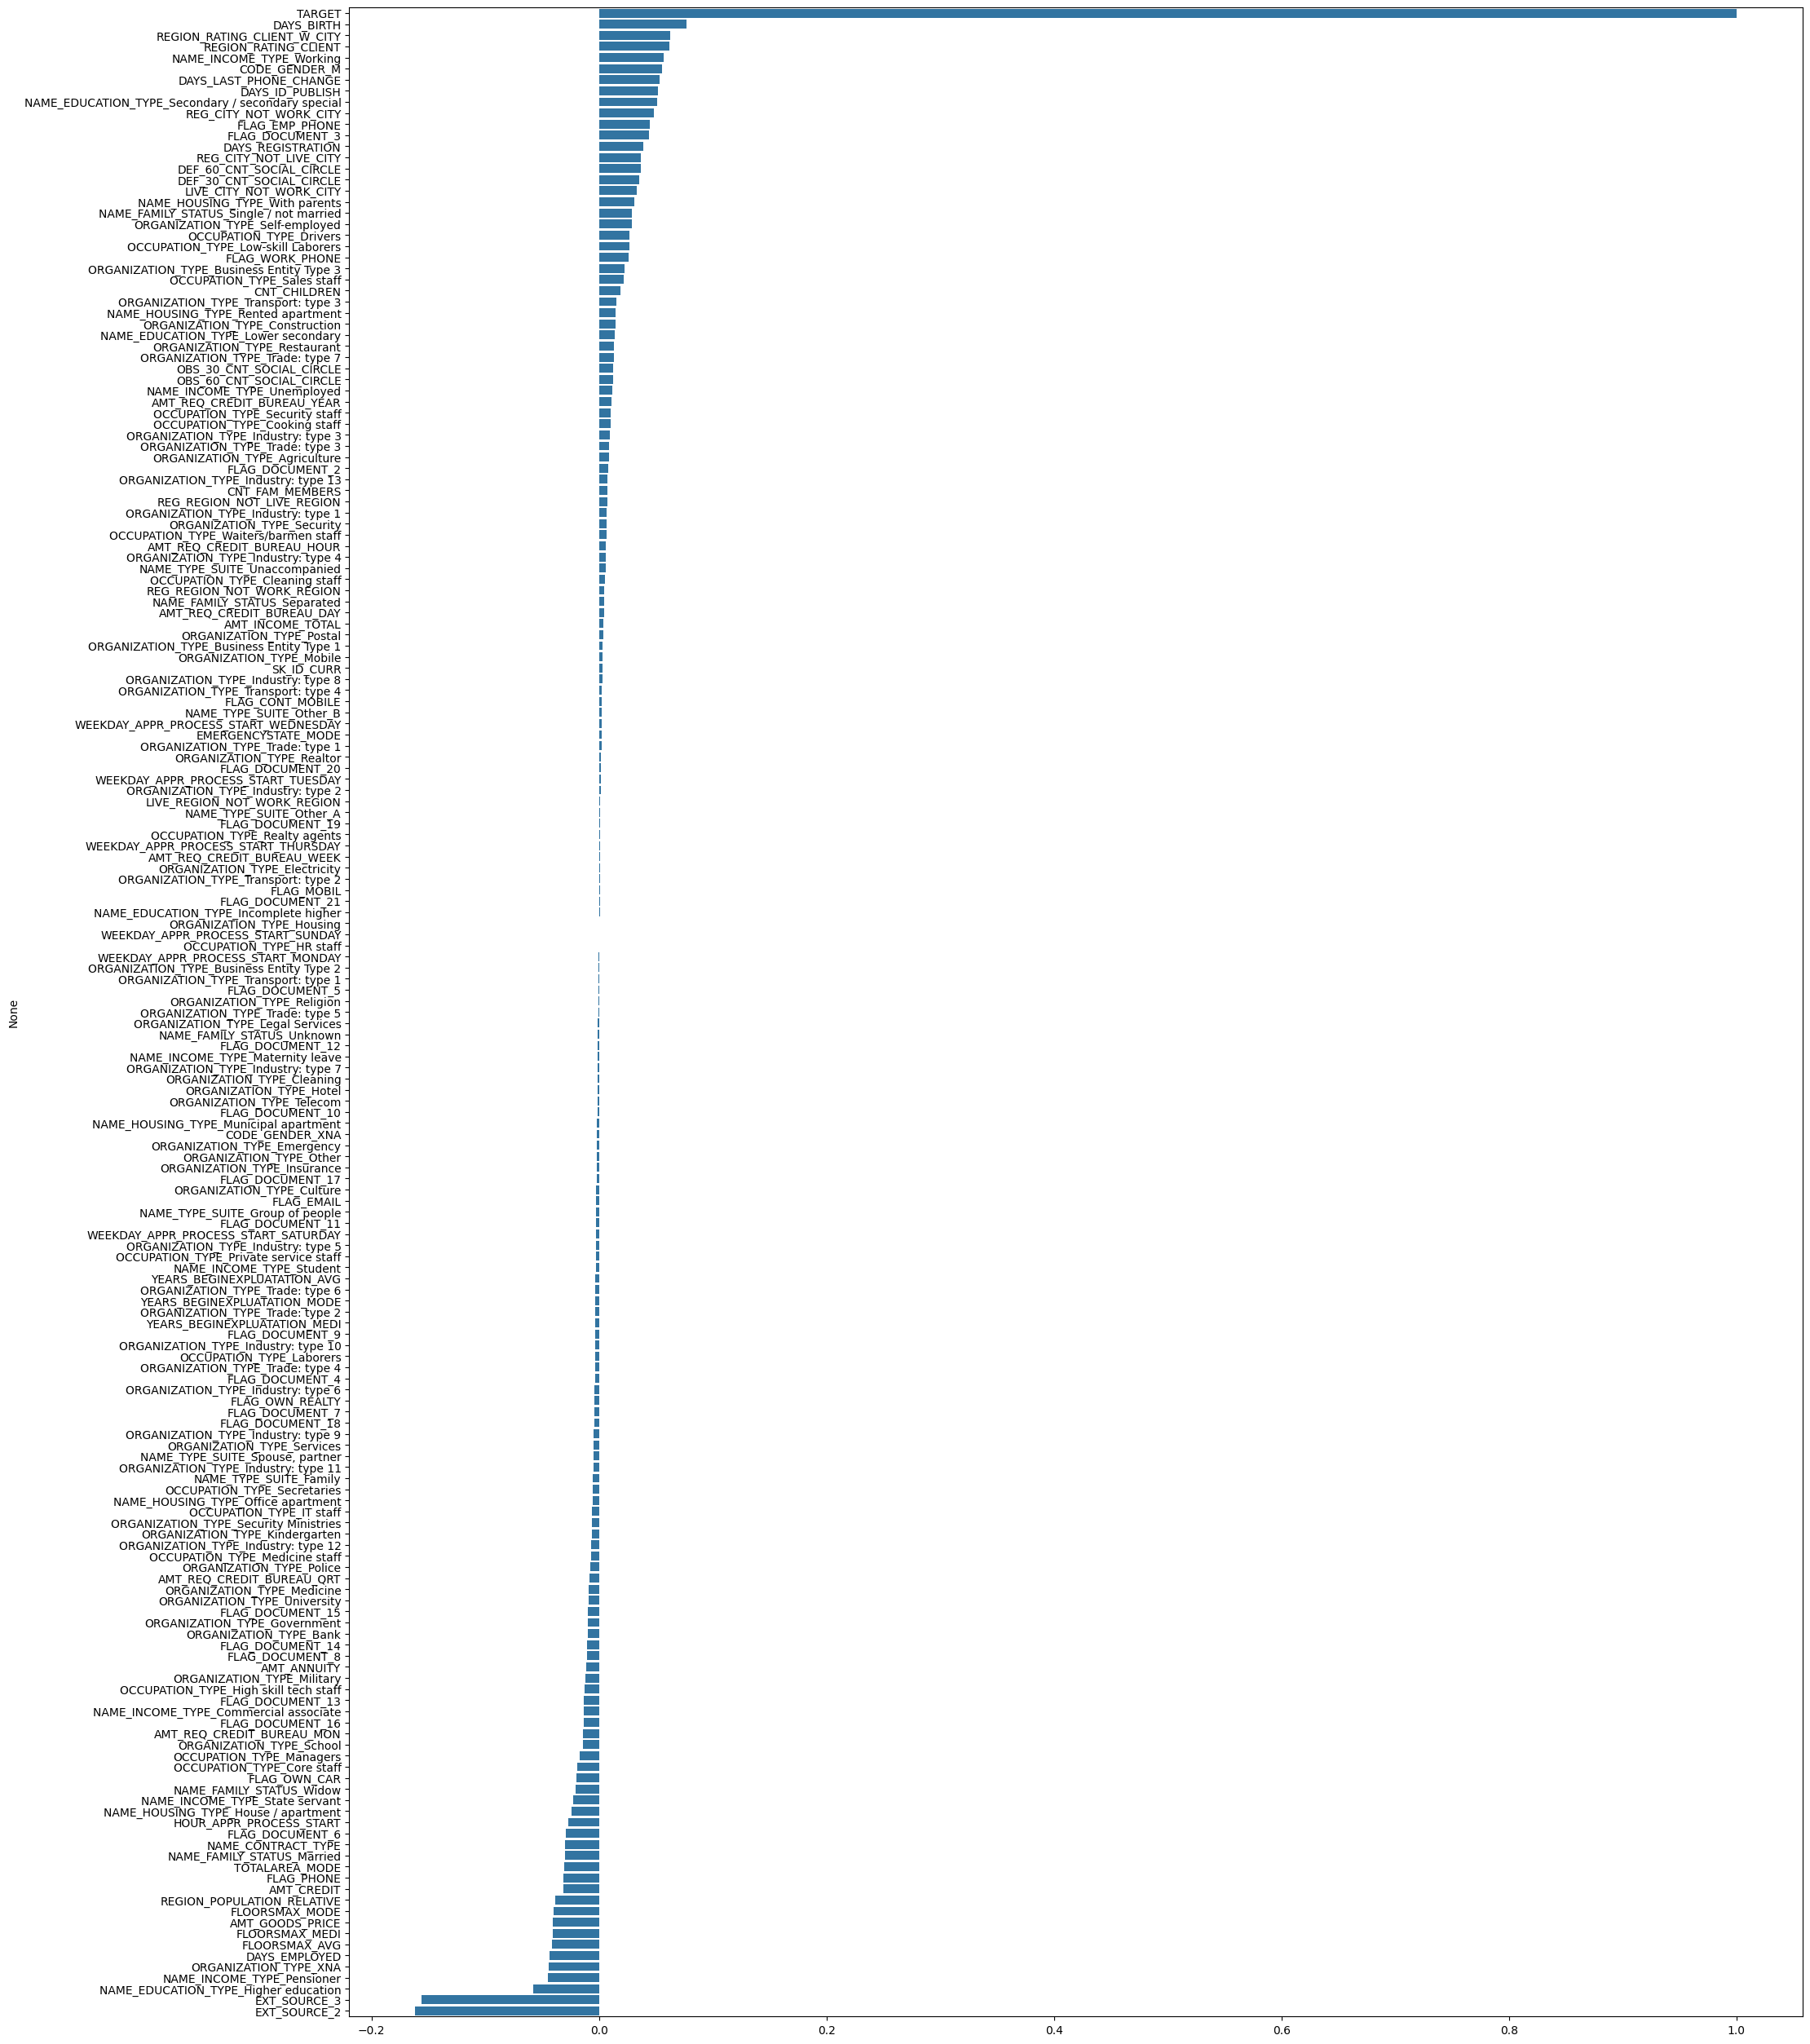

In [11]:
corr=df.corr()["TARGET"].sort_values(ascending=False)
print(corr)
plt.figure(figsize=(23,32))
sns.barplot(x=corr.values,y=corr.index)
plt.show()

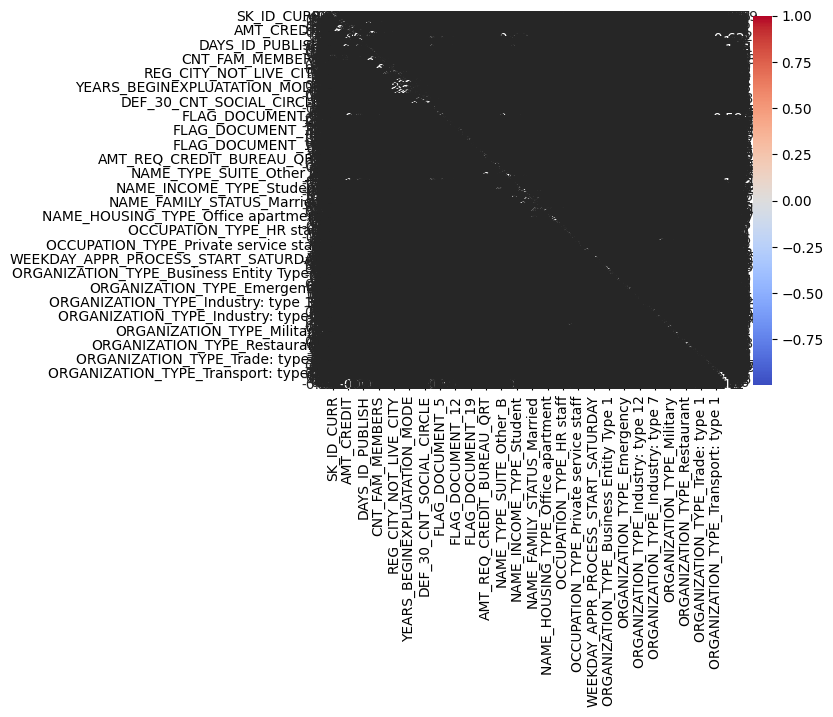

In [12]:
corr=df.corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

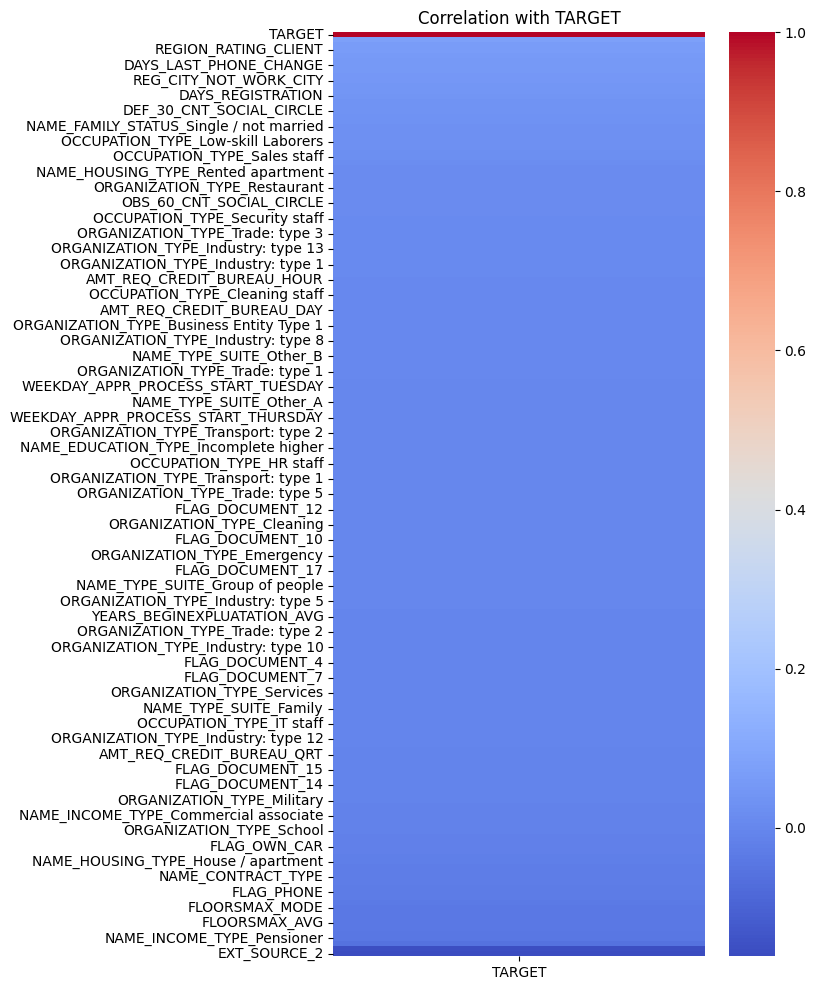

In [13]:
corr_target = df.corr()[['TARGET']].sort_values(by='TARGET', ascending=False)

plt.figure(figsize=(6,12))
sns.heatmap(corr_target, cmap="coolwarm")
plt.title("Correlation with TARGET")
plt.show()

In [16]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
X=df.drop("TARGET",axis=1,errors="ignore")
y=df["TARGET"]
mi=mutual_info_classif(X,y)
mi_scores=pd.Series(mi,index=X.columns)
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X,y)
rf_scores=pd.Series(rf.feature_importances_,index=X.columns)
feature_scores=pd.DataFrame({
    'MI':mi_scores,
    'Rf':rf_scores
})
feature_scores['MI_NORM']=feature_scores['MI']/feature_scores['MI'].max()
feature_scores['Rf_NORM']=feature_scores['Rf']/feature_scores['Rf'].max()

feature_scores['final']=(feature_scores['MI_NORM']+feature_scores['Rf_NORM'])/2
feature_scores=feature_scores.sort_values(by='final',ascending=False)
print(feature_scores)
selected_features=feature_scores.head(40).index
df=df[selected_features.tolist()+['TARGET']]

print(df.head())


                                                         MI  ...     final
EXT_SOURCE_3                                       0.014040  ...  0.779088
EXT_SOURCE_2                                       0.012254  ...  0.773399
AMT_ANNUITY                                        0.011079  ...  0.559020
FLAG_MOBIL                                         0.022411  ...  0.500008
NAME_EDUCATION_TYPE_Secondary / secondary special  0.019656  ...  0.473220
...                                                     ...  ...       ...
FLAG_DOCUMENT_17                                   0.000000  ...  0.000328
FLAG_DOCUMENT_15                                   0.000000  ...  0.000111
ORGANIZATION_TYPE_Trade: type 4                    0.000000  ...  0.000009
NAME_INCOME_TYPE_Maternity leave                   0.000000  ...  0.000000
NAME_INCOME_TYPE_Student                           0.000000  ...  0.000000

[180 rows x 5 columns]
   EXT_SOURCE_3  EXT_SOURCE_2  ...  OBS_30_CNT_SOCIAL_CIRCLE  TARGET
0      

In [19]:
df.corr()

,EXT_SOURCE_3,EXT_SOURCE_2,AMT_ANNUITY,FLAG_MOBIL,NAME_EDUCATION_TYPE_Secondary / secondary special,FLAG_OWN_REALTY,FLAG_CONT_MOBILE,FLAG_DOCUMENT_3,FLAG_EMP_PHONE,NAME_FAMILY_STATUS_Married,AMT_CREDIT,NAME_TYPE_SUITE_Unaccompanied,DAYS_EMPLOYED,NAME_HOUSING_TYPE_House / apartment,DAYS_BIRTH,NAME_INCOME_TYPE_Working,DAYS_ID_PUBLISH,OCCUPATION_TYPE_Laborers,DAYS_LAST_PHONE_CHANGE,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,SK_ID_CURR,TOTALAREA_MODE,HOUR_APPR_PROCESS_START,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,REGION_RATING_CLIENT_W_CITY,AMT_REQ_CREDIT_BUREAU_YEAR,REGION_RATING_CLIENT,FLOORSMAX_MODE,FLOORSMAX_MEDI,CODE_GENDER_M,FLAG_OWN_CAR,FLAG_PHONE,OBS_30_CNT_SOCIAL_CIRCLE,TARGET
EXT_SOURCE_3,1.000000,0.093934,0.025681,-0.000360,0.038705,0.034162,0.009793,-0.025797,-0.102849,0.019869,0.037443,-0.041051,0.101222,0.047032,-0.182512,-0.054749,-0.111028,0.050408,-0.066828,0.041571,-0.007779,-0.098429,-0.005654,0.003822,-0.037628,-0.023417,-0.025811,0.000953,0.006594,0.001694,0.000965,-0.008582,-0.075606,-0.008617,0.008209,0.006924,-0.016995,-0.015566,-0.001933,0.002023,-0.155862
EXT_SOURCE_2,0.093934,1.000000,0.125963,-0.000861,-0.108728,0.002084,-0.002583,-0.029616,0.019110,0.043283,0.133662,0.006904,-0.020458,0.034478,-0.092332,-0.068059,-0.053711,-0.037954,-0.196772,0.142785,0.201669,-0.060612,0.001050,0.088723,0.159169,0.032404,0.001617,-0.001086,0.124093,-0.000251,-0.000588,-0.291485,-0.008426,-0.295845,0.118612,0.122937,-0.016625,0.050216,0.058355,-0.017784,-0.161536
AMT_ANNUITY,0.025681,0.125963,1.000000,0.000257,-0.128133,-0.003237,0.020251,0.100399,0.106584,0.139439,0.773217,-0.017005,-0.107446,0.027493,0.009853,-0.039236,0.010787,-0.084458,-0.068652,0.777627,0.119878,0.035539,-0.000823,0.076082,0.049789,0.117665,0.080979,0.010425,0.109167,0.010905,0.011595,-0.141183,-0.008862,-0.127177,0.106282,0.108380,0.081804,0.140908,0.007890,-0.007296,-0.011244
FLAG_MOBIL,-0.000360,-0.000861,0.000257,1.000000,0.004956,-0.002103,-0.000142,0.004974,-0.001475,-0.002369,0.002520,-0.001522,0.001428,-0.001124,-0.005395,-0.003044,-0.004016,-0.003213,-0.000793,0.002452,0.002336,-0.000173,0.003747,-0.000815,-0.000913,0.000358,0.000542,-0.000930,-0.005281,-0.000979,-0.000992,0.000205,0.001378,0.000333,-0.005395,-0.005272,-0.004392,-0.004408,0.001963,0.001939,0.000938
NAME_EDUCATION_TYPE_Secondary / secondary special,0.038705,-0.108728,-0.128133,0.004956,1.000000,0.029172,0.021590,0.063707,-0.105382,0.001299,-0.107908,-0.041874,0.104852,0.011168,-0.157466,0.065956,-0.045378,0.145607,-0.001742,-0.120196,-0.065066,-0.097807,-0.000185,-0.093836,-0.085224,-0.054485,-0.016819,-0.002670,-0.129815,-0.003669,-0.004013,0.066766,0.055433,0.064245,-0.126046,-0.129269,0.006881,-0.089784,-0.033737,0.050905,0.051143
FLAG_OWN_REALTY,0.034162,0.002084,-0.003237,-0.002103,0.029172,1.000000,0.012758,-0.034962,-0.065190,0.021055,-0.038881,-0.054396,0.064878,0.219639,-0.120474,-0.030148,0.011648,0.028192,0.025637,-0.044953,0.013399,-0.023953,-0.003373,0.009239,-0.111486,0.002034,0.008511,-0.003153,0.005802,-0.002344,-0.002635,0.001130,0.057014,0.000639,0.006889,0.006050,-0.041386,0.002470,-0.039945,0.018889,-0.003953
FLAG_CONT_MOBILE,0.009793,-0.002583,0.020251,-0.000142,0.021590,0.012758,1.000000,0.007467,-0.015107,-0.000113,0.022200,-0.004457,0.015076,0.002439,-0.015402,0.005060,-0.000777,0.012011,-0.029727,0.019338,-0.011095,-0.001268,-0.000974,-0.005449,0.001272,-0.006865,0.003265,0.001924,-0.011119,0.002177,0.002225,0.016663,0.025230,0.015233,-0.010113,-0.011360,-0.011948,-0.013056,0.005940,0.007436,0.002675
FLAG_DOCUMENT_3,-0.025797,-0.029616,0.100399,0.004974,0.063707,-0.034962,0.007467,1.000000,0.246946,0.026288,0.093248,-0.014826,-0.247521,-0.004666,0.106360,0.165063,0.048310,-0.099380,-0.060391,0.071969,-0.085412,0.032077,0.001116,-0.050703,-0.016182,-0.010596,0.064931,0.000659,-0.069427,0.001058,0.000253,0.068280,0.048692,0.063004,-0.066474,

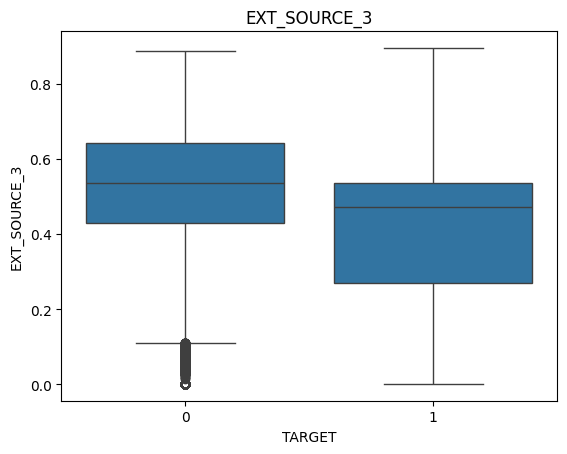

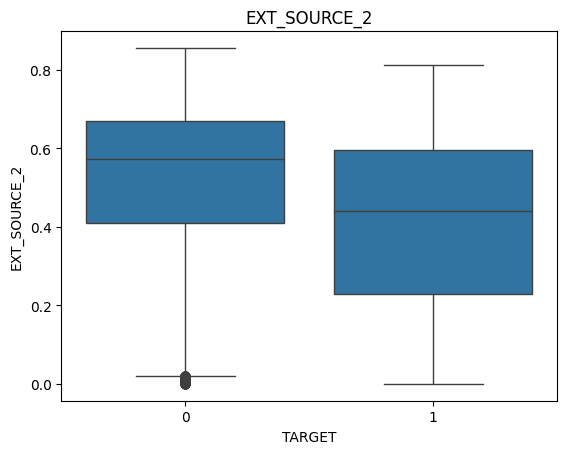

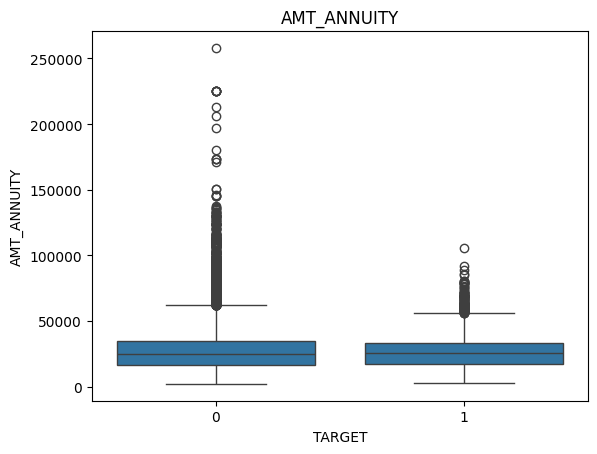

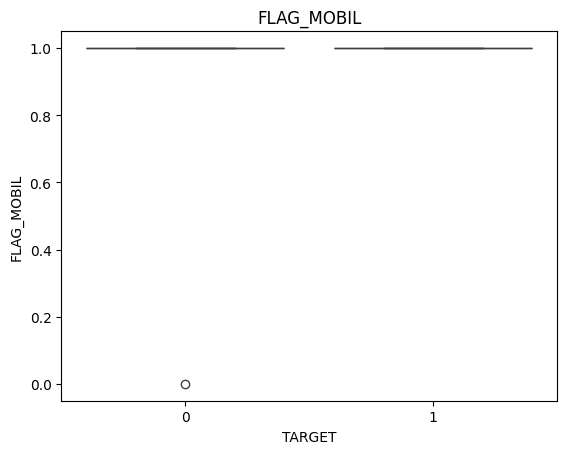

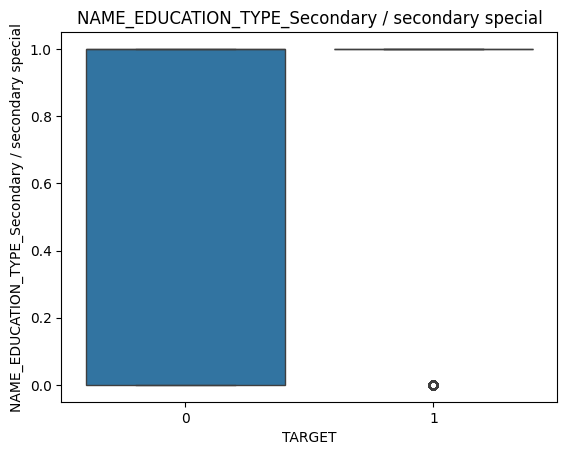

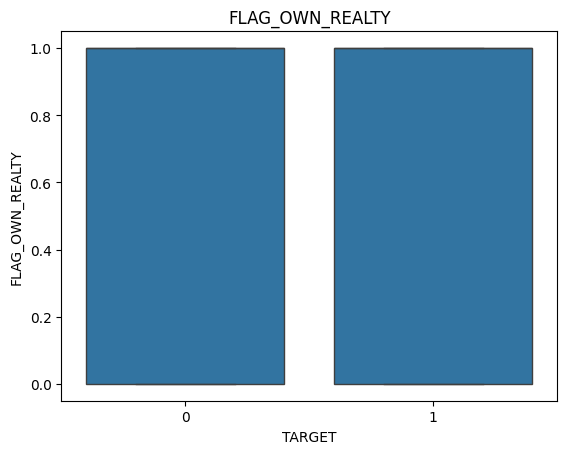

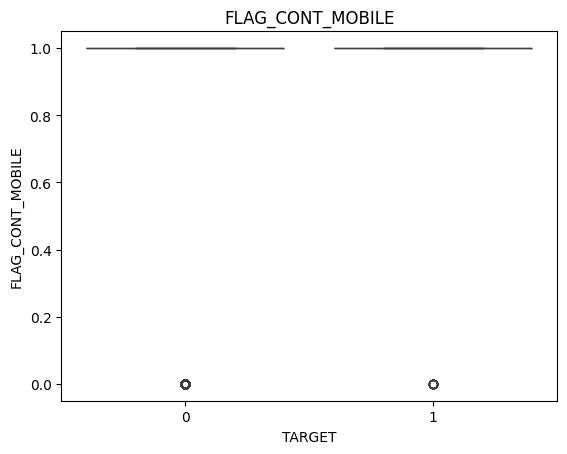

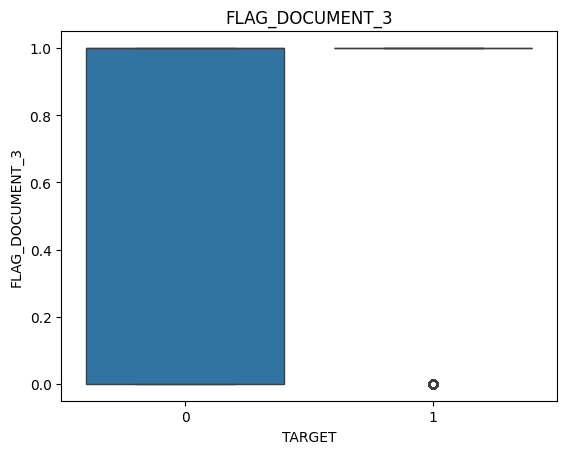

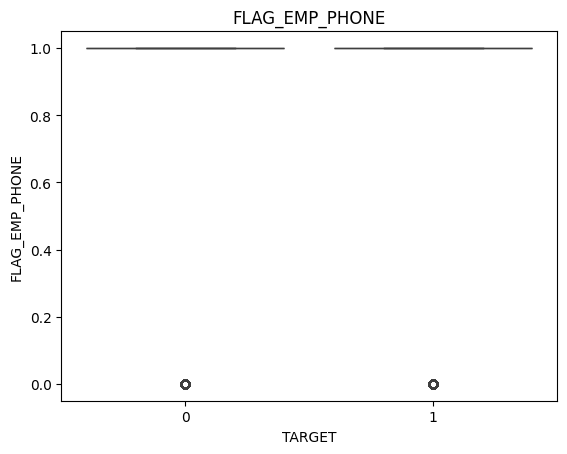

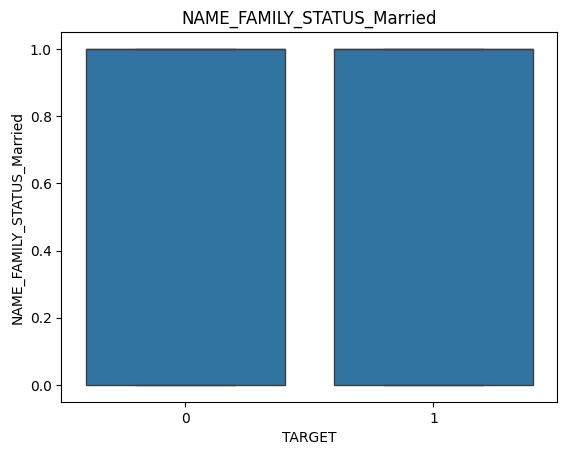

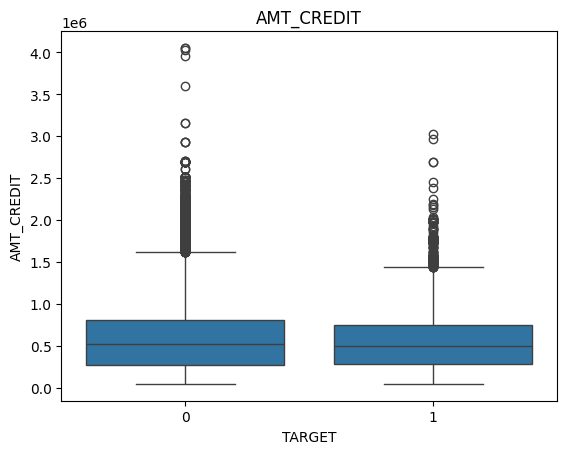

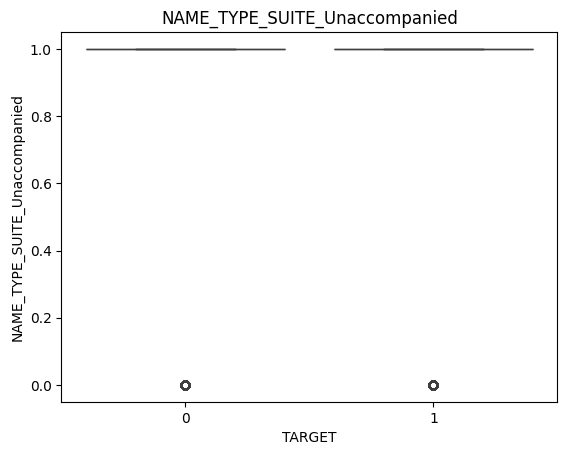

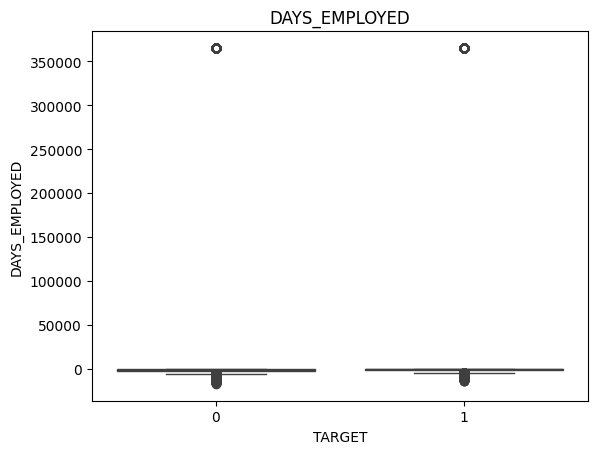

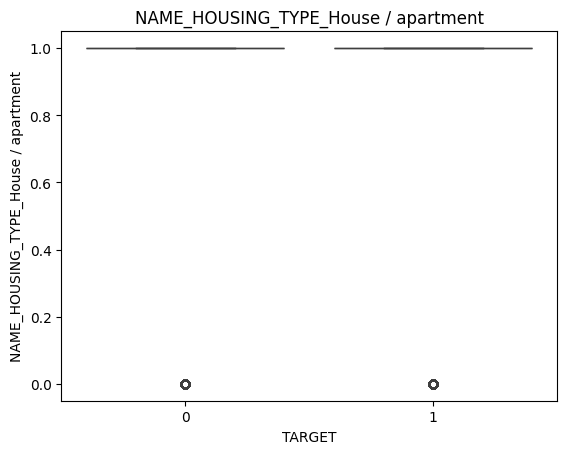

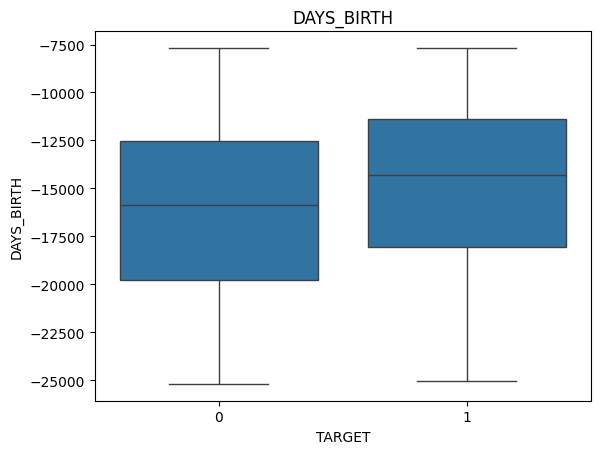

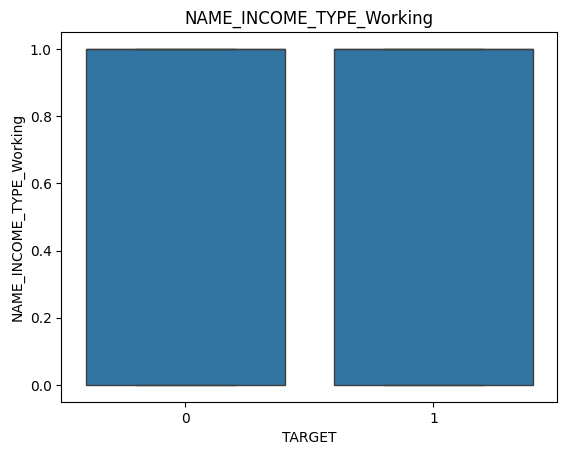

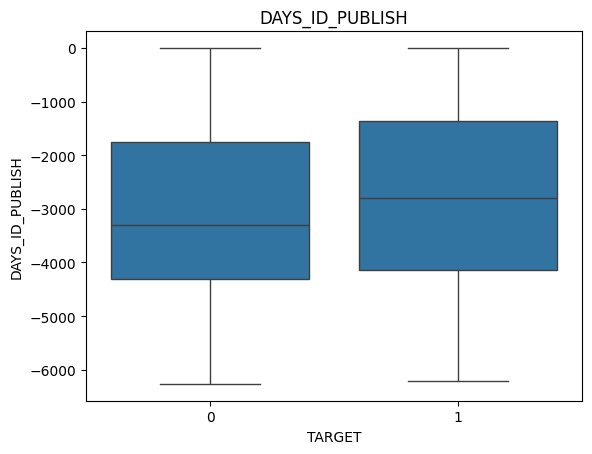

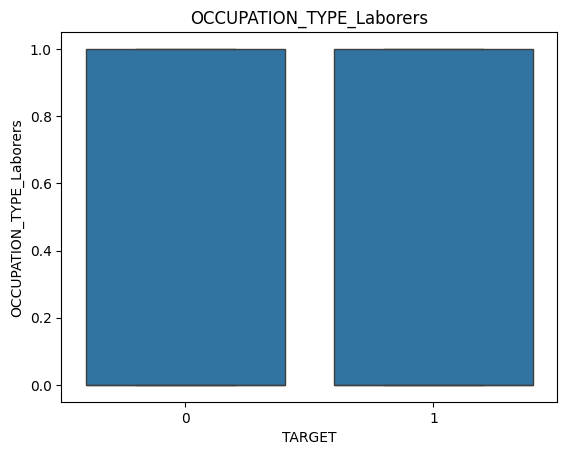

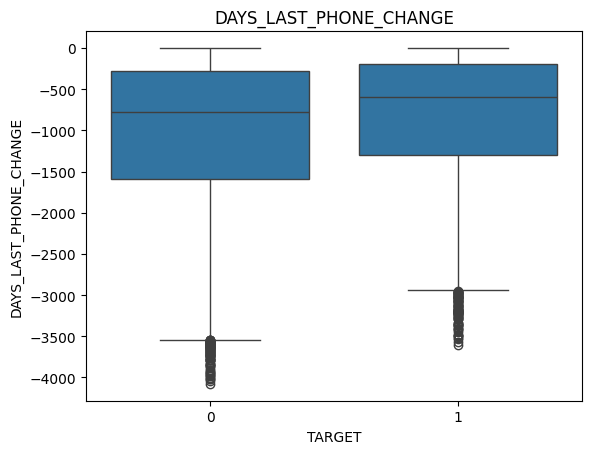

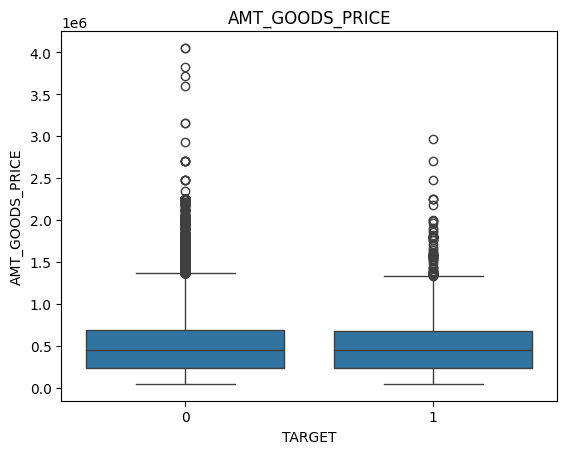

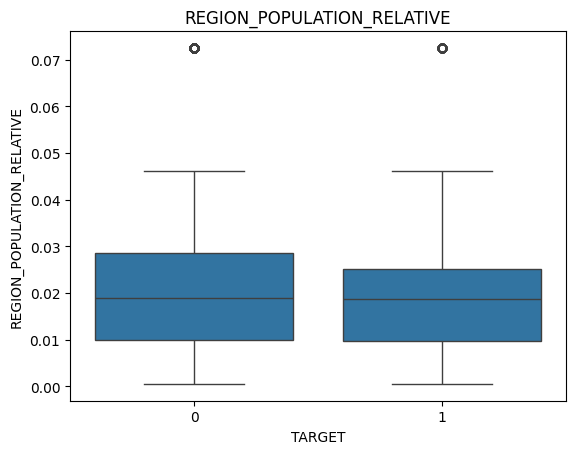

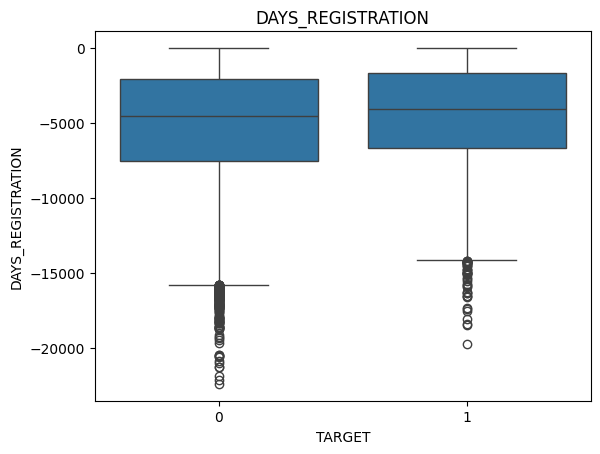

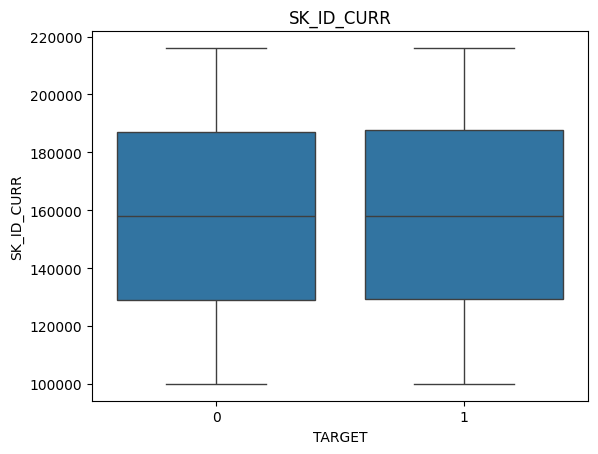

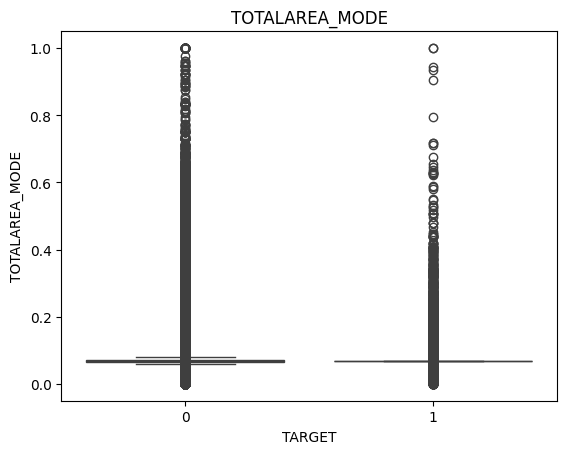

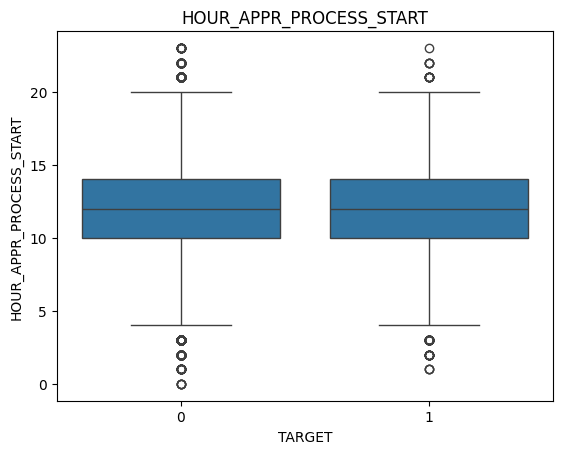

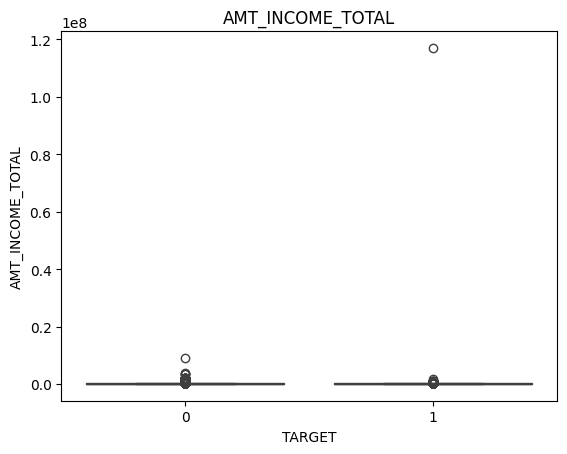

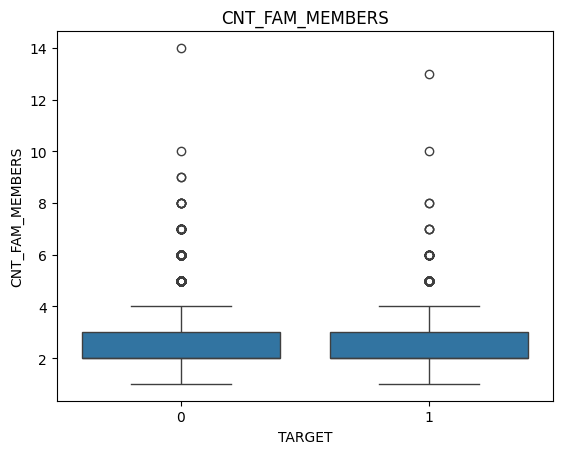

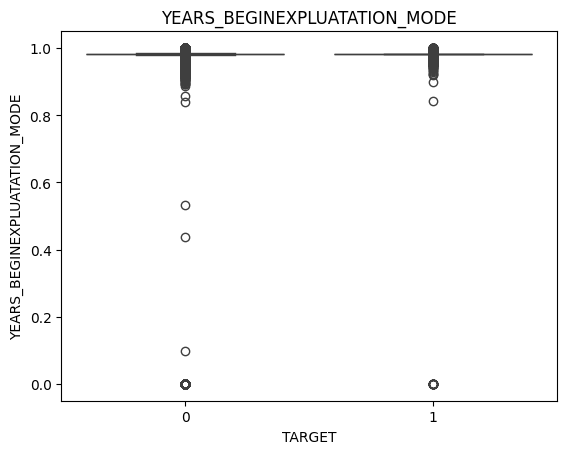

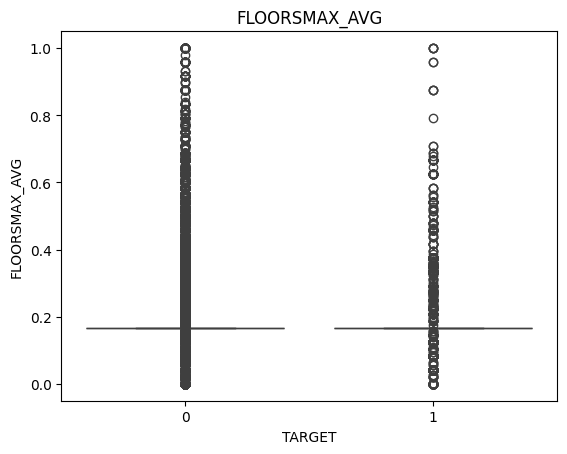

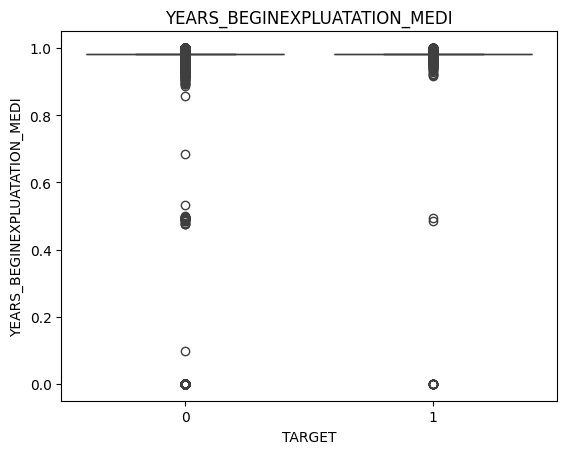

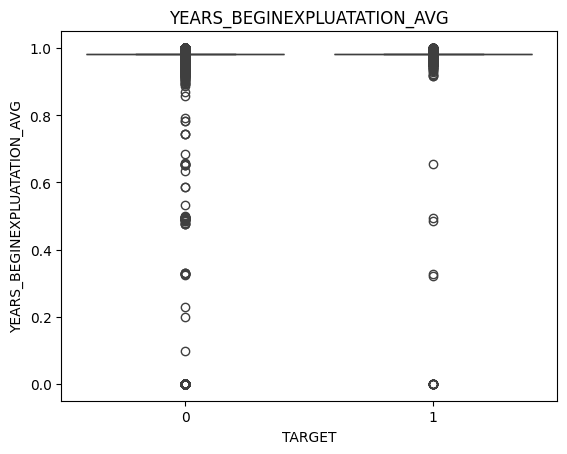

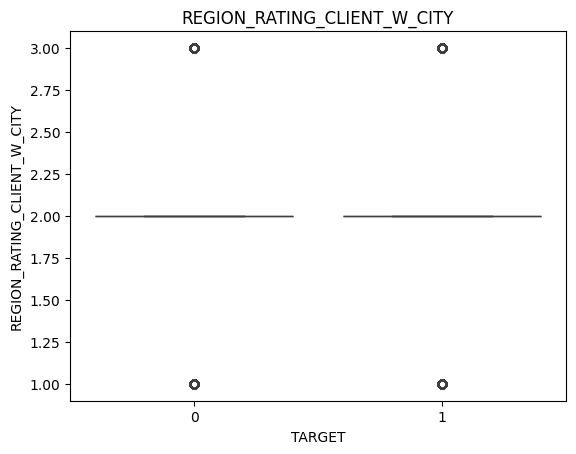

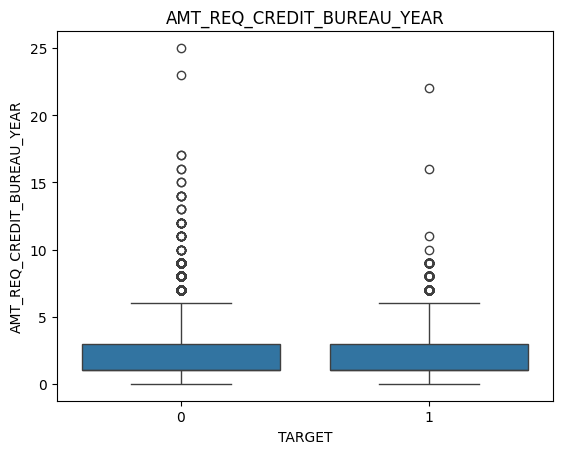

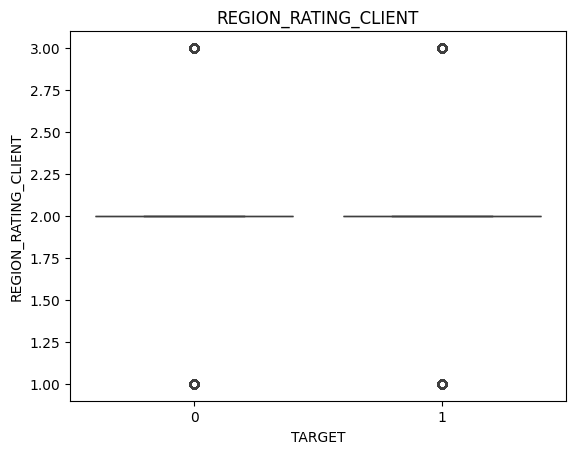

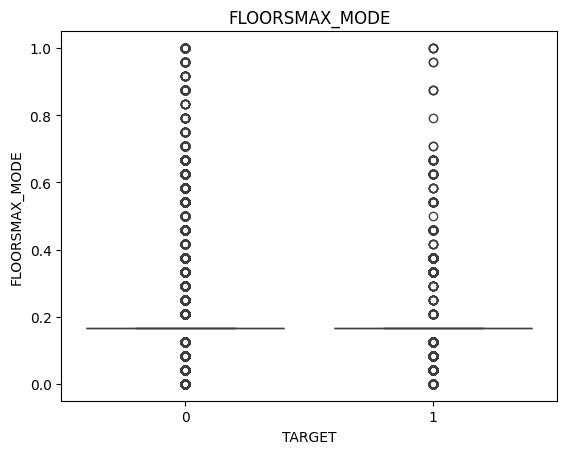

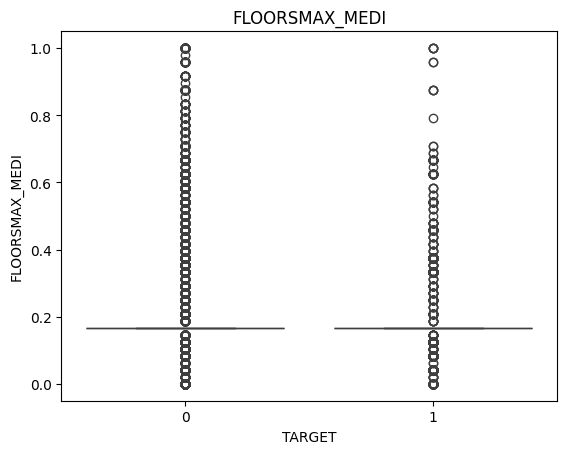

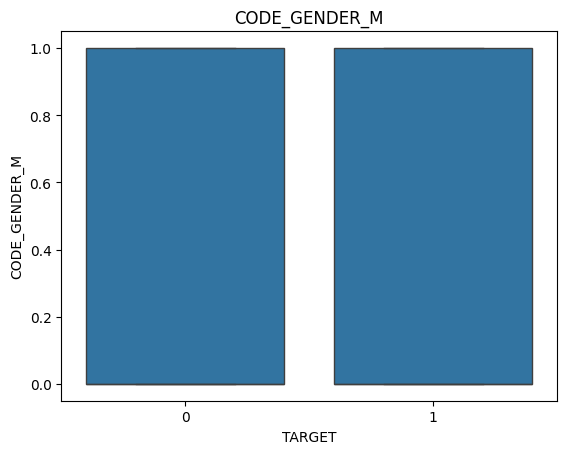

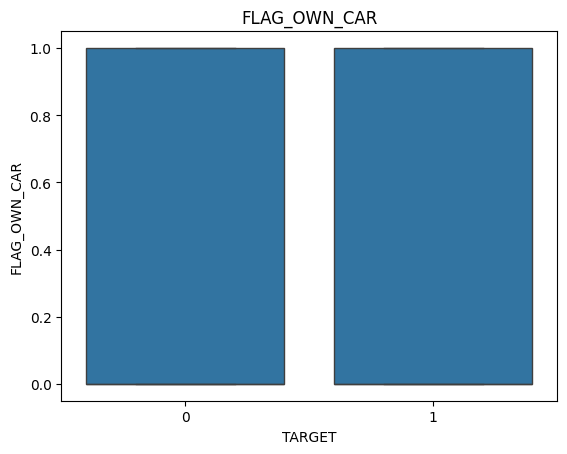

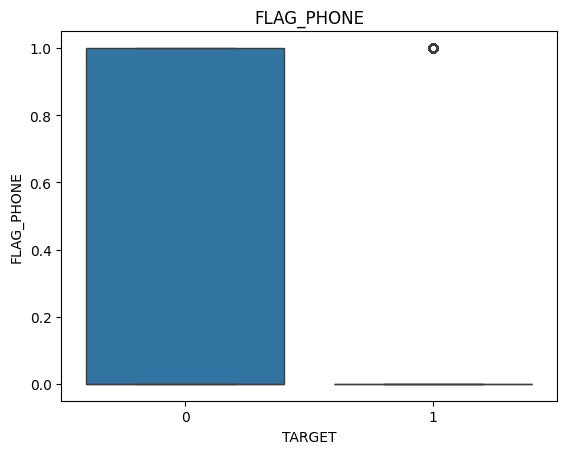

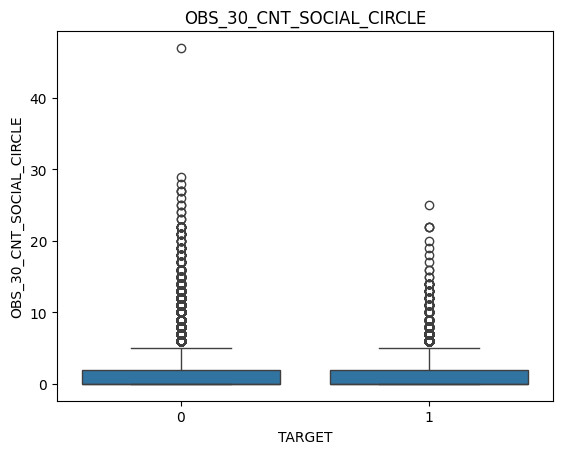

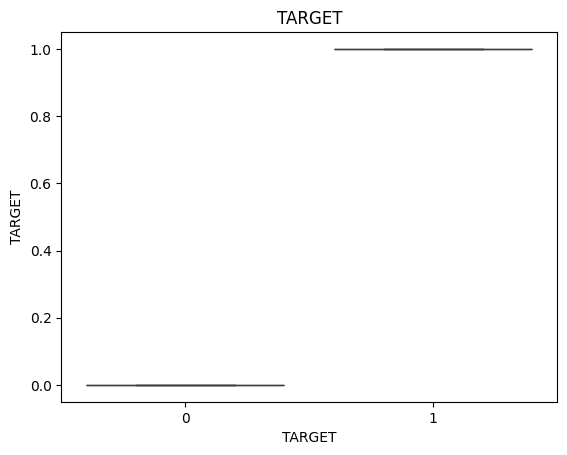

In [18]:
import seaborn as sns
for col in df :
    plt.Figure(figsize=(6,3))
    sns.boxplot(x='TARGET',y=col,data=df)
    plt.title(col)
    plt.show()